# Energy Efficiency Regression Model Selection

This notebook builds a regression workflow for the UCI Energy Efficiency dataset. It loads the building-shape and glazing variables, renames them into readable feature names, checks data quality, explores the training set, compares linear regression with regularized alternatives through cross-validation, and evaluates the selected model on a held-out test set.


In [131]:
import sys
sys.path.append("..")
from utils.utils import * 
from ucimlrepo import fetch_ucirepo 
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline, Pipeline
from scipy.stats import randint
import matplotlib.pyplot as plt



## Imports and Dataset Loading

The first step prepares the notebook environment by importing the utilities, numerical libraries, plotting tools, and scikit-learn components used throughout the workflow. The dataset is then fetched from the UCI repository, with the explanatory variables stored in `X` and the heating-load target stored in `y`.


In [132]:
energy_efficiency = fetch_ucirepo(id=242) 

X = energy_efficiency.data.features 
y = energy_efficiency.data.targets["Y1"].squeeze()

## Feature Naming and Initial Data Checks

The raw UCI variable names are replaced with descriptive feature names so the rest of the analysis is easier to read. The target is also renamed to `heating_load`, matching the regression task.

After these checks, `orientation` and `glazing_area_distribution` are removed because they are categorical layout descriptors and the following model-selection pipeline focuses on the remaining numeric predictors.



### Initial Feature Preview


,relative_compactness,surface_area,wall_area,roof_area,overall_height,orientation,glazing_area,glazing_area_distribution
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0


### Initial Target Preview


0    15.55
1    15.55
2    15.55
3    15.55
4    20.84
Name: heating_load, dtype: float64

### Feature Missing-Value Check


relative_compactness         0
surface_area                 0
wall_area                    0
roof_area                    0
overall_height               0
orientation                  0
glazing_area                 0
glazing_area_distribution    0
dtype: int64

### Target Missing-Value Check


np.int64(0)

### Feature Schema Summary
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   relative_compactness       768 non-null    float64
 1   surface_area               768 non-null    float64
 2   wall_area                  768 non-null    float64
 3   roof_area                  768 non-null    float64
 4   overall_height             768 non-null    float64
 5   orientation                768 non-null    int64  
 6   glazing_area               768 non-null    float64
 7   glazing_area_distribution  768 non-null    int64  
dtypes: float64(6), int64(2)
memory usage: 48.1 KB
### Target Schema Summary
<class 'pandas.core.series.Series'>
RangeIndex: 768 entries, 0 to 767
Series name: heating_load
Non-Null Count  Dtype  
--------------  -----  
768 non-null    float64
dtypes: float64(1)
memory usage: 6.1 KB
### Feature Distribution

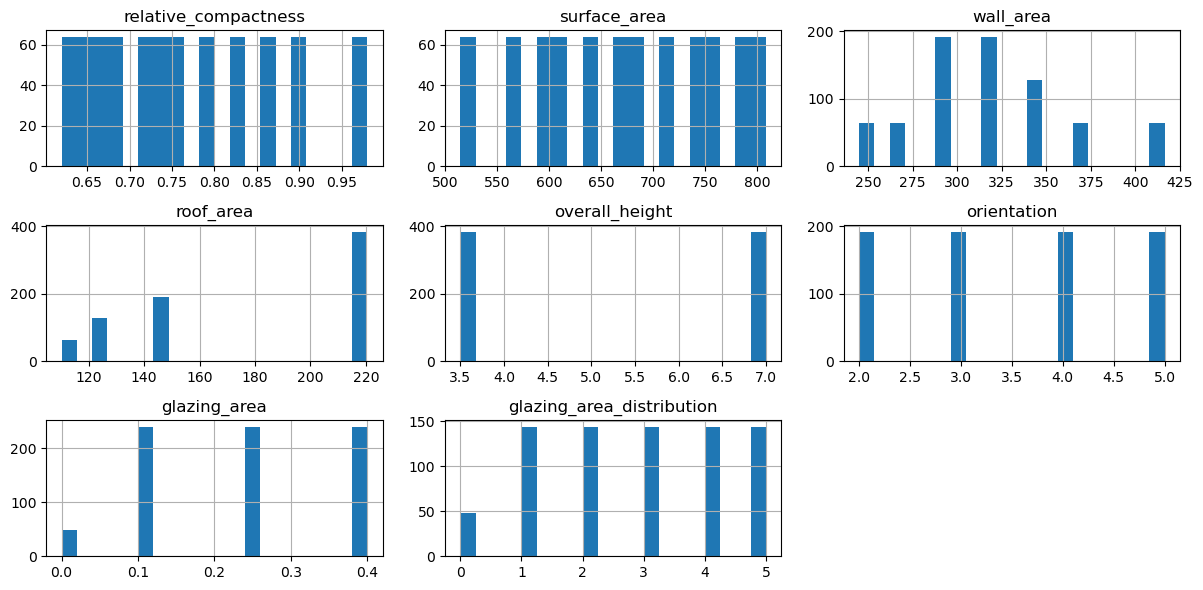

### Target Distribution


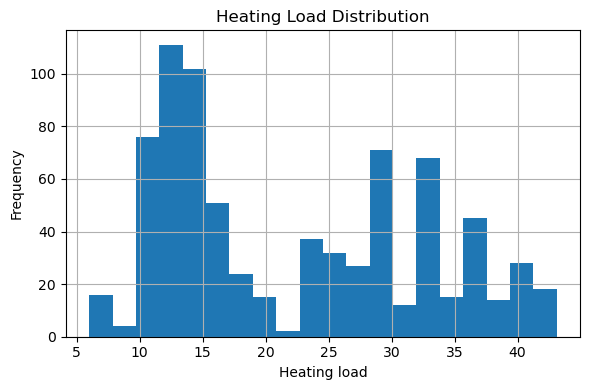

In [133]:
X = X.rename(columns={
    "X1": "relative_compactness",
    "X2": "surface_area",
    "X3": "wall_area",
    "X4": "roof_area",
    "X5": "overall_height",
    "X6": "orientation",
    "X7": "glazing_area",
    "X8": "glazing_area_distribution"
})

y = y.rename("heating_load")
print("### Initial Feature Preview")
display(X.head())
print("### Initial Target Preview")
display(y.head())
print("### Feature Missing-Value Check")
display(X.isnull().sum())
print("### Target Missing-Value Check")
display(y.isnull().sum())
print("### Feature Schema Summary")
X.info()
print("### Target Schema Summary")
y.info()
print("### Feature Distributions")
X.hist(figsize=(12, 6), bins=20)
plt.tight_layout()
plt.show()
print("### Target Distribution")
plt.figure(figsize=(6, 4))
y.hist(bins=20)
plt.title("Heating Load Distribution")
plt.xlabel("Heating load")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()



## Train/Test Split and Exploratory Checks

The dataset is split into training and test subsets before fitting any model, keeping the test set untouched for the final evaluation. The following outputs summarize the training data and help confirm that the split is ready for preprocessing and model selection.



### Training Feature Preview


,relative_compactness,surface_area,wall_area,roof_area,overall_height,orientation,glazing_area,glazing_area_distribution
60,0.82,612.5,318.5,147.0,7.0,2,0.10,1
618,0.64,784.0,343.0,220.5,3.5,4,0.40,2
346,0.86,588.0,294.0,147.0,7.0,4,0.25,2
294,0.90,563.5,318.5,122.5,7.0,4,0.25,1
231,0.66,759.5,318.5,220.5,3.5,5,0.10,4


### Training Target Preview


60     23.53
618    18.90
346    29.27
294    32.84
231    11.43
Name: heating_load, dtype: float64

### Training Feature Missing-Value Check


relative_compactness         0
surface_area                 0
wall_area                    0
roof_area                    0
overall_height               0
orientation                  0
glazing_area                 0
glazing_area_distribution    0
dtype: int64

### Training Target Missing-Value Check


np.int64(0)

### Training Feature Schema Summary
<class 'pandas.core.frame.DataFrame'>
Index: 614 entries, 60 to 102
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   relative_compactness       614 non-null    float64
 1   surface_area               614 non-null    float64
 2   wall_area                  614 non-null    float64
 3   roof_area                  614 non-null    float64
 4   overall_height             614 non-null    float64
 5   orientation                614 non-null    int64  
 6   glazing_area               614 non-null    float64
 7   glazing_area_distribution  614 non-null    int64  
dtypes: float64(6), int64(2)
memory usage: 43.2 KB
### Training Target Schema Summary
<class 'pandas.core.series.Series'>
Index: 614 entries, 60 to 102
Series name: heating_load
Non-Null Count  Dtype  
--------------  -----  
614 non-null    float64
dtypes: float64(1)
memory usage: 9.6 KB
### Training F

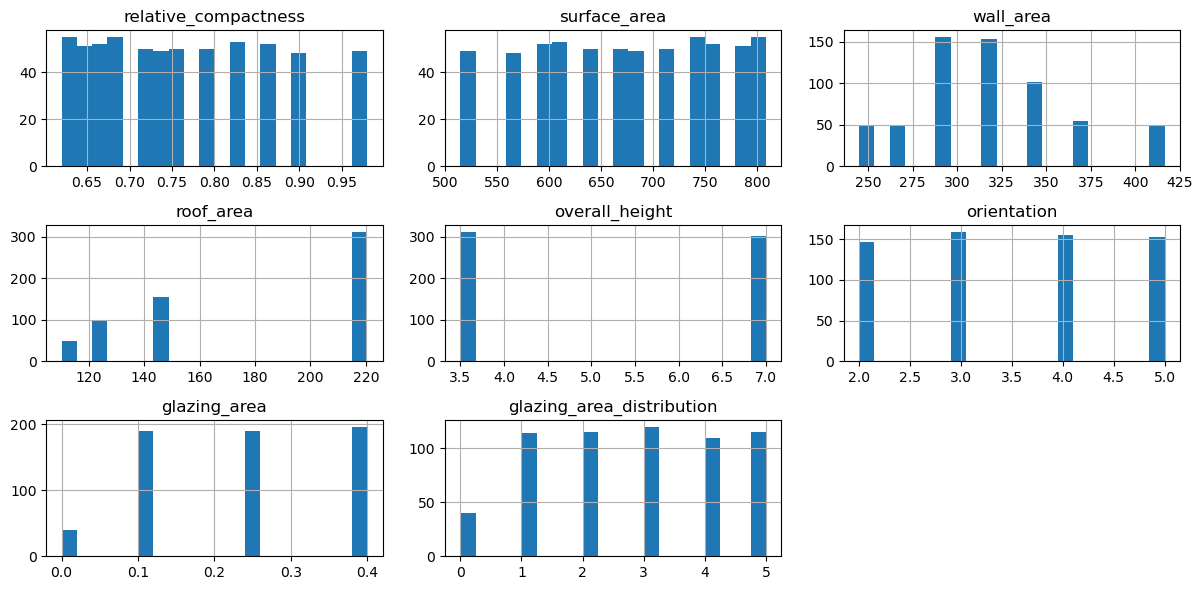

### Training Target Distribution


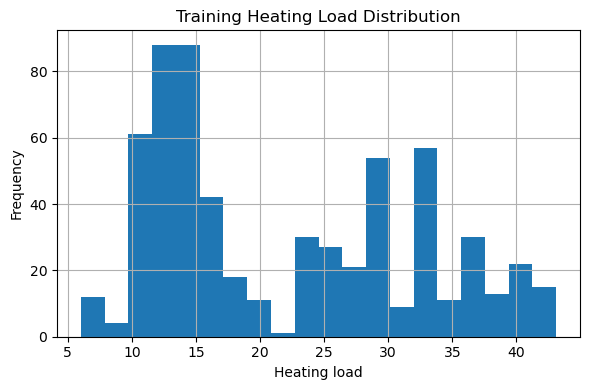

### Feature-to-Target Correlation


relative_compactness    0.622272
surface_area           -0.658120
wall_area               0.455671
roof_area              -0.861828
overall_height          0.889431
glazing_area            0.269841
Name: target, dtype: float64

In [134]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("### Training Feature Preview")
display(X_train.head())
print("### Training Target Preview")
display(y_train.head())
print("### Training Feature Missing-Value Check")
display(X_train.isnull().sum())
print("### Training Target Missing-Value Check")
display(y_train.isnull().sum())
print("### Training Feature Schema Summary")
X_train.info()
print("### Training Target Schema Summary")
y_train.info()
print("### Training Feature Distributions")
X_train.hist(figsize=(12, 6), bins=20)
plt.tight_layout()
plt.show()
print("### Training Target Distribution")
plt.figure(figsize=(6, 4))
y_train.hist(bins=20)
plt.title("Training Heating Load Distribution")
plt.xlabel("Heating load")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

data_corr = X.copy()
data_corr["target"] = y
corr_with_y = data_corr.corr()["target"].drop(["orientation", "glazing_area_distribution", "target"])
print("### Feature-to-Target Correlation")
display(corr_with_y)



## Preprocessing

The preprocessing stage standardizes all numeric predictors with `StandardScaler`. Scaling is especially useful here because the model search includes Ridge and Lasso regression, whose regularization penalties are sensitive to feature scale. The `ColumnTransformer` keeps this step explicit and ready to be embedded inside the full modeling pipeline.


In [135]:
num_pipeline = make_pipeline(
    StandardScaler()
)

cat_pipeline = make_pipeline(
    OneHotEncoder(handle_unknown="ignore")
)

num_columns = [
    "relative_compactness",
    "surface_area",
    "wall_area",
    "roof_area",
    "overall_height",
    "glazing_area"
]

cat_columns = [
    "orientation",
    "glazing_area_distribution"
]

preprocessing = ColumnTransformer([
    ("num", num_pipeline, num_columns),
    ("cat", cat_pipeline, cat_columns)
])

## Model Selection

A single scikit-learn pipeline combines preprocessing with the regression model, ensuring that scaling is learned only from the training folds during cross-validation. `GridSearchCV` compares ordinary linear regression with Ridge and Lasso models across several regularization strengths, using 5-fold cross-validation and R-squared as the selection metric.



In [136]:
pipe = Pipeline([
    ("preprocessing", preprocessing),
    ("model", LinearRegression())
]
)


param_grid = [
    {
        "model": [LinearRegression()]
    },
    {
        "model": [Ridge(max_iter=10000, random_state=42)],
        "model__alpha": [0.001, 0.01, 0.1, 1, 10, 100]
    },
    {
        "model": [Lasso(max_iter=10000, random_state=42)],
        "model__alpha": [0.001, 0.01, 0.1, 1, 10, 100]
    }
]

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=5,
    scoring="r2"
)

grid.fit(X_train, y_train)
best_model = grid.best_estimator_
print("### Cross-Validation Scores")
display(grid.cv_results_["mean_test_score"])
print("### Best Selected Pipeline")
best_model



### Cross-Validation Scores


array([ 0.92051461,  0.92051481,  0.92051658,  0.92053042,  0.92045141,
        0.91700426,  0.88943923,  0.92055331,  0.92056858,  0.91534335,
        0.88413866, -0.0042631 , -0.0042631 ])

### Best Selected Pipeline


,steps,"[('preprocessing', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## Evaluation

The selected pipeline is evaluated on the held-out test set, which was not used during cross-validation. This final step estimates how well the chosen preprocessing and regression model generalize to unseen building configurations.



### Test-Set Regression Metrics
Test R2: 0.9203458335167733
Test MSE: 8.30247721702449
Test RMSE: 2.8814019533943003
Test MAE: 2.0830548145298136


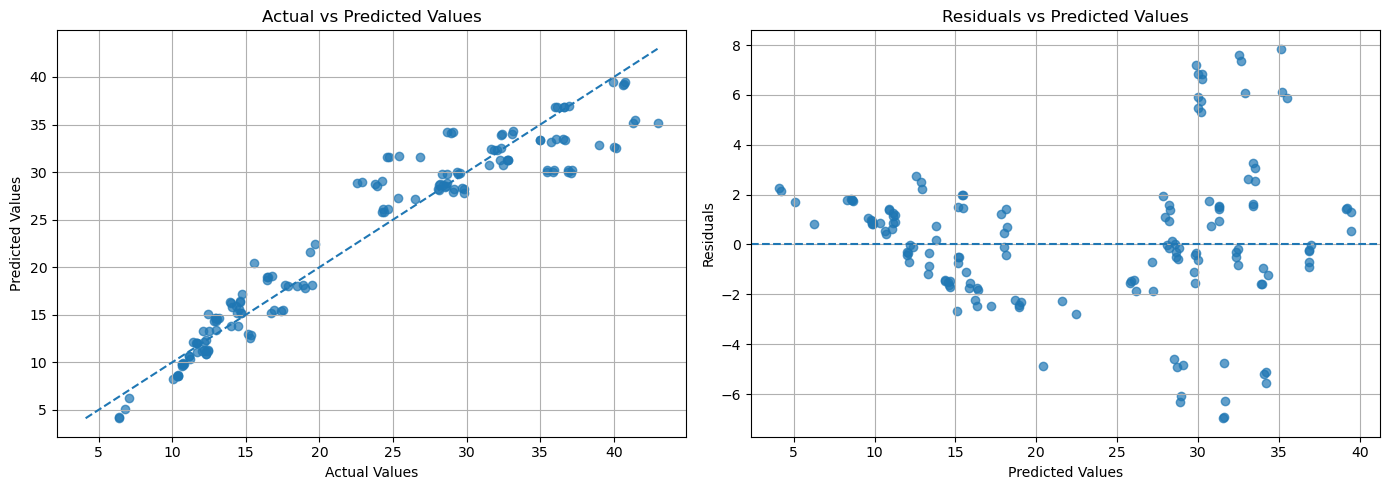

In [137]:
print("### Test-Set Regression Metrics")
evaluate_regression(best_model, X_test, y_test)

